<a href="https://colab.research.google.com/github/24cseaiml046asutoshpanda-web/AML-Lab-3/blob/main/EXP-4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [244]:
import numpy as np

data = np.array([
    ['s1', 1, 2],
    ['s2', 2, 3],
    ['s3', 3, 4]
])

In [245]:
df = pd.DataFrame(data)
print(df)

    0  1  2
0  s1  1  2
1  s2  2  3
2  s3  3  4


In [246]:
w = 0
b = 0
learning_rate = 0.01

history = []
cost = []
history.append([w, b])

In [247]:
print(df[1][2])

3


In [248]:
for i in range(10):

  print("\n\n--------Iteration  "+ str(i+1 )+"---------")
  gd = {}

  for j in range(len(df)):
    y_pred = (w * int(df[1][j])) + b
    gd[df[0][j]] = y_pred

  print("Predicted values (gd):", gd)
  print("-----------------\n")

  losses = {}
  for j in range(len(df)):
    actual_value = int(df[2][j])
    predicted_value = gd[df[0][j]]
    l = actual_value - predicted_value
    losses[df[0][j]] = l ** 2

  print("Squared losses:", losses)
  print("Cost (J):", str((sum(losses.values()))/len(df)))
  cost.append((sum(losses.values()))/len(df))
  print("-----------------\n")


  # Calculate sum_sqrt_loss_times_feature for dw
  sum_sqrt_loss_times_feature = 0
  for j in range(len(df)):
    squared_loss = losses[df[0][j]]
    feature_value = int(df[1][j])
    sum_sqrt_loss_times_feature += (squared_loss ** 0.5) * feature_value
  print("Sum of (sqrt(loss) * feature_value) for dw:", sum_sqrt_loss_times_feature)

  dw = -((2  / len(df)) * sum_sqrt_loss_times_feature)
  print("Gradient for weight (dw):", dw)
  print("-----------------\n")


  # Calculate sum_sqrt_loss for jb
  sum_sqrt_loss = 0
  for j in range(len(df)):
    squared_loss = losses[df[0][j]]
    sum_sqrt_loss += (squared_loss ** 0.5)
  print("Sum of sqrt(loss) for jb:", sum_sqrt_loss)
  print("-----------------\n")


  jb = -((2  / len(df)) * sum_sqrt_loss)
  print("Gradient for bias (jb):", jb)

  print("-----------------\n")


  bnew = b - (learning_rate * jb)
  b = bnew

  wnew = w - (learning_rate * dw)
  w = wnew
  print("Updated bias (b):", bnew)
  print("Updated weight (w):", wnew)

  history.append([wnew, bnew])

  print("-----------------\n")



--------Iteration  1---------
Predicted values (gd): {'s1': 0, 's2': 0, 's3': 0}
-----------------

Squared losses: {'s1': 4, 's2': 9, 's3': 16}
Cost (J): 9.666666666666666
-----------------

Sum of (sqrt(loss) * feature_value) for dw: 20.0
Gradient for weight (dw): -13.333333333333332
-----------------

Sum of sqrt(loss) for jb: 9.0
-----------------

Gradient for bias (jb): -6.0
-----------------

Updated bias (b): 0.06
Updated weight (w): 0.13333333333333333
-----------------



--------Iteration  2---------
Predicted values (gd): {'s1': 0.19333333333333333, 's2': 0.32666666666666666, 's3': 0.46}
-----------------

Squared losses: {'s1': 3.2640444444444445, 's2': 7.146711111111111, 's3': 12.531600000000001}
Cost (J): 7.647451851851852
-----------------

Sum of (sqrt(loss) * feature_value) for dw: 17.773333333333333
Gradient for weight (dw): -11.848888888888888
-----------------

Sum of sqrt(loss) for jb: 8.02
-----------------

Gradient for bias (jb): -5.346666666666666
----------

In [249]:
print(history)

[[0, 0], [0.13333333333333333, 0.06], [0.2518222222222222, 0.11346666666666666], [0.3571134814814815, 0.16112444444444443], [0.45067124543209874, 0.2036174162962963], [0.5337972325399176, 0.2415182181530864], [0.6076487621100686, 0.275335964488428], [0.6732547724002584, 0.3055232947142567], [0.7315300618543307, 0.3324826379239612], [0.7832879505643013, 0.35657178269130874], [0.8292515372039808, 0.3781088290149105]]


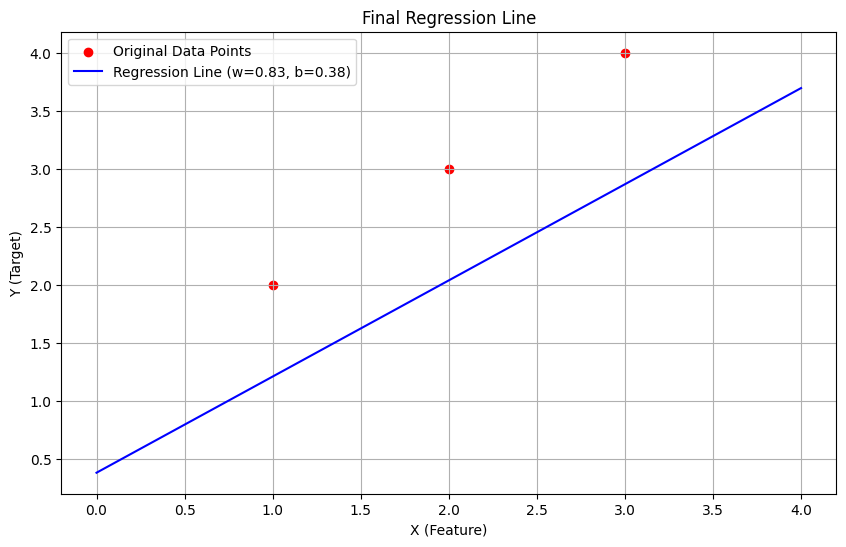

In [250]:
import matplotlib.pyplot as plt

w_history = [item[0] for item in history]
b_history = [item[1] for item in history]

iterations = range(len(history))

# Get the final w and b values
final_w = w_history[-1]
final_b = b_history[-1]

# Extract x and y values from the DataFrame
x_values = [int(val) for val in df[1]]
y_values = [int(val) for val in df[2]]

# Create a range of x values for the regression line
x_min = min(x_values)
x_max = max(x_values)
x_reg_line = [i for i in range(x_min - 1, x_max + 2)] # Extend the line a bit beyond data points
y_reg_line = [final_w * x + final_b for x in x_reg_line]

plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, color='red', label='Original Data Points')
plt.plot(x_reg_line, y_reg_line, color='blue', label=f'Regression Line (w={final_w:.2f}, b={final_b:.2f})')
plt.xlabel('X (Feature)')
plt.ylabel('Y (Target)')
plt.title('Final Regression Line')
plt.legend()
plt.grid(True)
plt.show()

In [251]:
print(cost)

[9.666666666666666, 7.647451851851852, 6.051339448230453, 4.7896670258009255, 3.792351673865911, 3.003996598262063, 2.3808135946572517, 1.8881904282527422, 1.4987679775141958, 1.190920319109502]


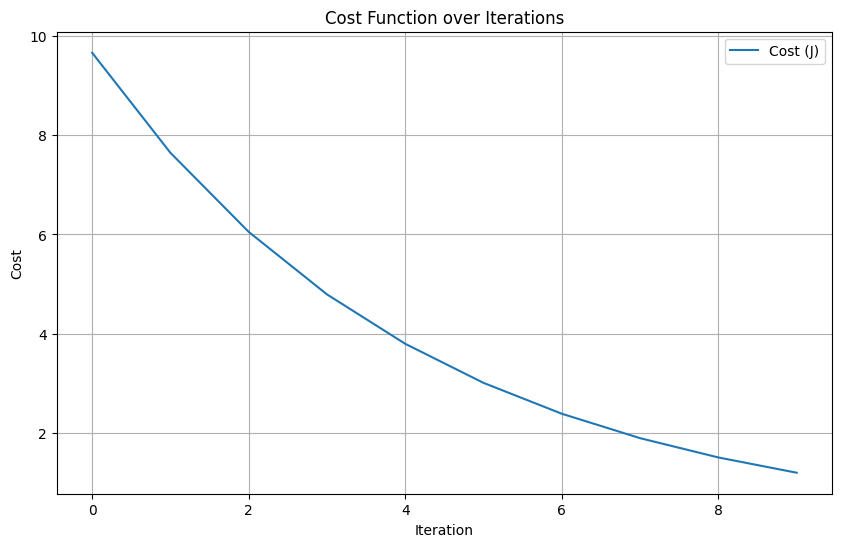

In [252]:
plt.figure(figsize=(10, 6))
plt.plot(range(len(cost)), cost, label='Cost (J)')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost Function over Iterations')
plt.legend()
plt.grid(True)
plt.show()